# Variante 2: Multiprocessing Static
Bilder werden aufgeteilt (np.array_split). Jeder Prozess bekommt seinen Chunk und arbeitet ihn sequenziell ab.

Hypothese: Static ist bei gleicher Auflösung (NIH) effizient, weil alle Chunks gleich lang dauern. Bei variabler Auflösung (Kaggle Pneumonia) kann ein Prozess zufällig viele große Bilder bekommen und zum Flaschenhals werden.

Technologie: multiprocessing.Process + numpy.array_split

#### Imports

In [ ]:
import sys
from scipy import stats

#from static_utils import run_static
import multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import statistics
from pathlib import Path

from pipeline import process_image, get_image_paths

print(f"CPU-Kerne verfügbar: {multiprocessing.cpu_count()}")

CPU-Kerne verfügbar: 8


#### Konfiguration
Hinweis: Bitte an eigenes lokales Set-Up anpassen
(Laptop 1 = Maxim, Laptop 2 = Ella, Laptop 3 = Jordan)

In [2]:
LAPTOP_ID = 2

IMG_SIZE = (512, 512)
RUNS = 10

NIH_DIR            = "../data/nih_chest_xray"
KAGGLE_DIR         = "../data/kaggle_pneumonia"

RESULTS_DIR        = f"results/laptop{LAPTOP_ID}"
RESULTS_CSV        = f"{RESULTS_DIR}/results_static_laptop{LAPTOP_ID}.csv"

IMAGE_COUNTS = [100, 500, 1000, 5000]
PROCESS_COUNTS = [1, 2, 4, 8]

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

#### 1. Get Images

In [3]:
nih_paths    = get_image_paths(NIH_DIR)
kaggle_paths = get_image_paths(KAGGLE_DIR)

print(f"NIH Bilder gefunden:             {len(nih_paths)}")
print(f"Kaggle Pneumonia Bilder gefunden: {len(kaggle_paths)}")

NIH Bilder gefunden:             5000
Kaggle Pneumonia Bilder gefunden: 5000


#### 2. Process Image

In [ ]:
#Funktion die jeder Prozess ausführt, bekommt Chunk, process_image zum Verarbeiten, Ergebnisse in reutrn_list
def worker_static(chunk, return_list):
    local = [process_image(path) for path in chunk]
    return_list.extend(local)


def run_static(image_paths, n_processes):
    chunks = [list(c) for c in np.array_split(image_paths, n_processes) if len(c) > 0] #aufteilen

    #Prozesse haben eigene Speicher, manager.list() liegt in einem separaten Verwaltungsprozess auf den alle schreiben. Flaschenhals weil alle Prozesse sequenziell reinschreiben, und das BS muss 8 Prozesse koordinieren (das ist sequenzieller Overhead der nach Amdahls Gesetz den Speedup begrenzt).
    manager     = multiprocessing.Manager()
    return_list = manager.list()

    processes = [
        multiprocessing.Process(target=worker_static, args=(chunk, return_list))
        for chunk in chunks
    ]

    # start der Parallelisierung und join, damit alle Ergebnisse gesammelt werden wenn alle Prozesse fertig sind (sonst leere Ergebnisse)
    t_start = time.perf_counter()
    for p in processes: p.start()
    for p in processes: p.join()
    total_time = time.perf_counter() - t_start

    return total_time, list(return_list)

#### 3. Run

In [5]:
def benchmark():
    rows = []

    datasets = [
        ("NIH",              nih_paths),
        ("Kaggle Pneumonia", kaggle_paths),
    ]

    #4 verschachtelte Schleifen:
    #Datensatz (2x)
    for dataset_name, all_paths in datasets:
        print(f"\n=== {dataset_name} ===")

        #Bildanzahl (4x: 100, 500, 1000, 5000)
        for n_img in IMAGE_COUNTS:
            subset = all_paths[:n_img]
            if len(subset) < n_img:
                print(f"  Nur {len(subset)} Bilder verfügbar (angefragt: {n_img})")
                continue

            #Prozessanzahl (4x: 1, 2, 4, 8)
            for n_proc in PROCESS_COUNTS:
                runtimes = []

                #Runs (10x)
                for run in range(RUNS):
                    runtime, _ = run_static(subset, n_proc)
                    runtimes.append(runtime)

                median_runtime    = statistics.median(runtimes)
                median_throughput = n_img / median_runtime
                std_runtime       = statistics.stdev(runtimes)
                ci                = stats.t.interval(0.95, df=len(runtimes)-1, loc=median_runtime, scale=stats.sem(runtimes))

                rows.append({
                    "Laptop":        LAPTOP_ID,
                    "Variante":      "Static",
                    "Datensatz":     dataset_name,
                    "Bilder":        n_img,
                    "Prozesse":      n_proc,
                    "Laufzeit in s": round(median_runtime, 3),
                    "Std":           round(std_runtime, 4),
                    "CI_low":        round(ci[0], 4),
                    "CI_high":       round(ci[1], 4),
                    "Speedup":       None,
                    "Efficiency":    None,
                    "Throughput":    round(median_throughput, 2),
                    "all_times": str(runtimes),
                })
                print(f"  {n_img} Bilder | {n_proc} Prozesse | Median: {median_runtime:.3f}s ± {std_runtime:.4f}s")

    return pd.DataFrame(rows)

df = benchmark()
df


=== NIH ===
  100 Bilder | 1 Prozesse | Median: 0.686s
  100 Bilder | 2 Prozesse | Median: 0.569s
  100 Bilder | 4 Prozesse | Median: 0.551s
  100 Bilder | 8 Prozesse | Median: 0.747s
  500 Bilder | 1 Prozesse | Median: 3.506s
  500 Bilder | 2 Prozesse | Median: 2.145s
  500 Bilder | 4 Prozesse | Median: 1.612s
  500 Bilder | 8 Prozesse | Median: 1.558s
  1000 Bilder | 1 Prozesse | Median: 7.584s
  1000 Bilder | 2 Prozesse | Median: 4.316s
  1000 Bilder | 4 Prozesse | Median: 2.775s
  1000 Bilder | 8 Prozesse | Median: 2.322s
  5000 Bilder | 1 Prozesse | Median: 37.009s
  5000 Bilder | 2 Prozesse | Median: 22.445s
  5000 Bilder | 4 Prozesse | Median: 13.252s
  5000 Bilder | 8 Prozesse | Median: 9.936s

=== Kaggle Pneumonia ===
  100 Bilder | 1 Prozesse | Median: 1.150s
  100 Bilder | 2 Prozesse | Median: 0.899s
  100 Bilder | 4 Prozesse | Median: 0.888s
  100 Bilder | 8 Prozesse | Median: 1.220s
  500 Bilder | 1 Prozesse | Median: 6.425s
  500 Bilder | 2 Prozesse | Median: 3.799s
  50

,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,1,Static,NIH,100,1,0.686,None,None,145.74
1,1,Static,NIH,100,2,0.569,None,None,175.87
2,1,Static,NIH,100,4,0.551,None,None,181.62
3,1,Static,NIH,100,8,0.747,None,None,133.85
4,1,Static,NIH,500,1,3.506,None,None,142.63
5,1,Static,NIH,500,2,2.145,None,None,233.15
6,1,Static,NIH,500,4,1.612,None,None,310.15
7,1,Static,NIH,500,8,1.558,None,None,320.91
8,1,Static,NIH,1000,1,7.584,None,None,131.86
9,1,Static,NIH,1000,2,4.316,None,None,231.71


#### 4. Speedup und Efficiency
Efficiency = Speedup / Anzahl Prozesse

In [6]:
baseline = (
    df[df["Prozesse"] == 1]
    .set_index(["Datensatz", "Bilder"])["Laufzeit in s"]
)

df["Speedup"]   = df.apply(lambda r: round(baseline.get((r["Datensatz"], r["Bilder"]), float("nan")) / r["Laufzeit in s"], 3), axis=1)
df["Efficiency"] = df.apply(lambda r: round(r["Speedup"] / r["Prozesse"], 3), axis=1)

df.to_csv(RESULTS_CSV, index=False)
print(f"Gespeichert: {RESULTS_CSV}")
df

Gespeichert: results/laptop1/results_static_laptop1.csv


,Laptop,Variante,Datensatz,Bilder,Prozesse,Laufzeit in s,Speedup,Efficiency,Throughput
0,1,Static,NIH,100,1,0.686,1.000,1.000,145.74
1,1,Static,NIH,100,2,0.569,1.206,0.603,175.87
2,1,Static,NIH,100,4,0.551,1.245,0.311,181.62
3,1,Static,NIH,100,8,0.747,0.918,0.115,133.85
4,1,Static,NIH,500,1,3.506,1.000,1.000,142.63
5,1,Static,NIH,500,2,2.145,1.634,0.817,233.15
6,1,Static,NIH,500,4,1.612,2.175,0.544,310.15
7,1,Static,NIH,500,8,1.558,2.250,0.281,320.91
8,1,Static,NIH,1000,1,7.584,1.000,1.000,131.86
9,1,Static,NIH,1000,2,4.316,1.757,0.878,231.71


#### 5. Plots

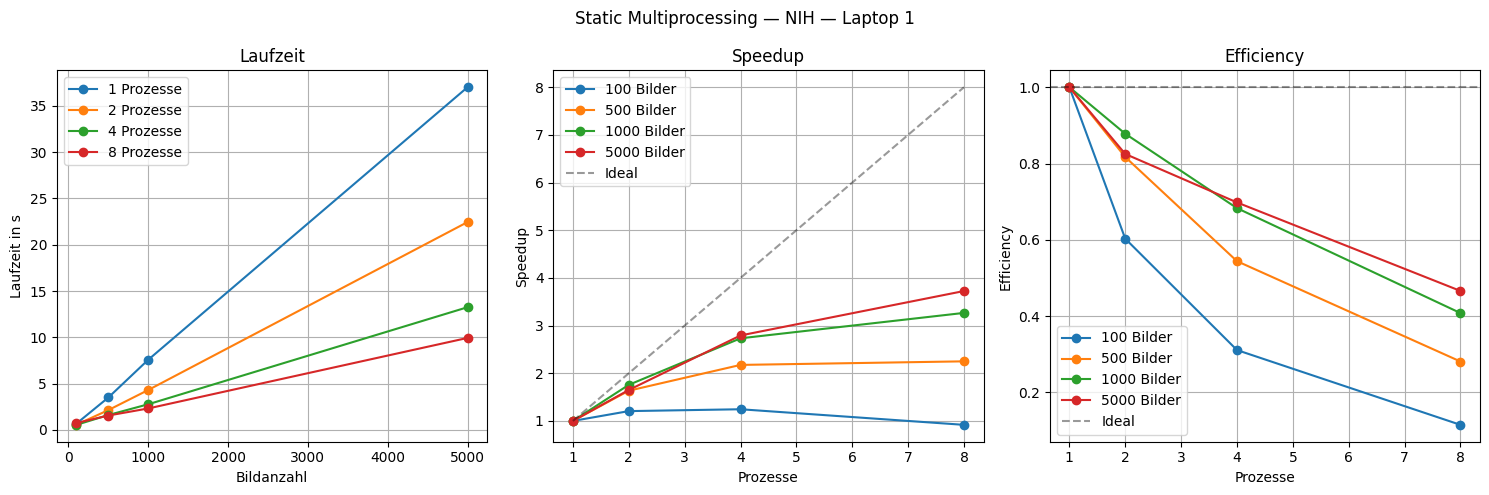

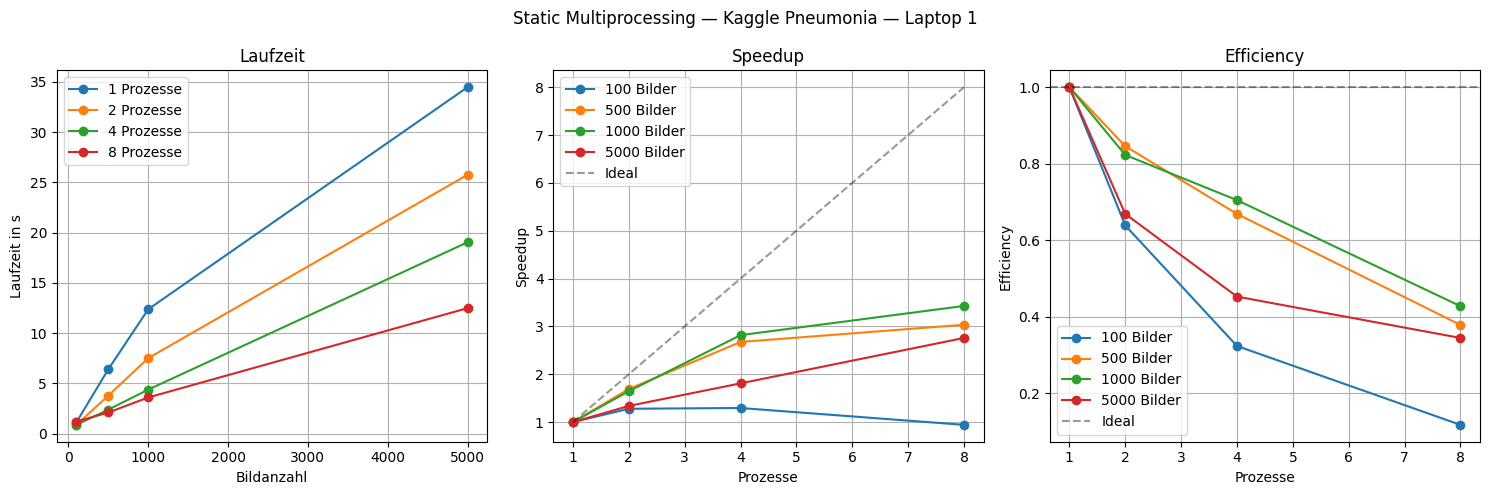

In [7]:
Path("plots").mkdir(exist_ok=True)

for dataset_name in ["NIH", "Kaggle Pneumonia"]:
    sub_ds = df[df["Datensatz"] == dataset_name]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Static Multiprocessing — {dataset_name} — Laptop {LAPTOP_ID}")

    ax = axes[0]
    for n_proc in PROCESS_COUNTS:
        sub = sub_ds[sub_ds["Prozesse"] == n_proc]
        ax.errorbar(sub["Bilder"], sub["Laufzeit in s"],
                    yerr=sub["Std"], marker="o", capsize=4, label=f"{n_proc} Prozesse")
    ax.set_xlabel("Bildanzahl")
    ax.set_ylabel("Laufzeit in s")
    ax.set_title("Laufzeit")
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.errorbar(sub["Prozesse"], sub["Speedup"],
                        yerr=sub["Std"], marker="o", capsize=4, label=f"{n_img} Bilder")
    ax.plot(PROCESS_COUNTS, PROCESS_COUNTS, "k--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Speedup")
    ax.set_title("Speedup")
    ax.legend()
    ax.grid(True)

    ax = axes[2]
    for n_img in IMAGE_COUNTS:
        sub = sub_ds[sub_ds["Bilder"] == n_img]
        if not sub.empty:
            ax.errorbar(sub["Prozesse"], sub["Efficiency"],
                        yerr=sub["Std"], marker="o", capsize=4, label=f"{n_img} Bilder")
    ax.axhline(1.0, color="k", linestyle="--", alpha=0.4, label="Ideal")
    ax.set_xlabel("Prozesse")
    ax.set_ylabel("Efficiency")
    ax.set_title("Efficiency")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    fname = f"{RESULTS_DIR}/static_{dataset_name.lower().replace(' ', '_')}_laptop{LAPTOP_ID}.png"
    plt.savefig(fname, dpi=150)
   # plt.show()